## Author
Sarang Kale

https://www.linkedin.com/in/sarang-kale-42818a2a4/


# 📊 Mini Project: Churn Prediction


## "I chose this project to show how a business can use data to spot customers who might leave and figure out the best way to keep them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


warnings.filterwarnings("ignore")

%matplotlib inline


## 🔹  Importing the Dataset

In [ ]:
df = pd.read_excel("Telco_customer_churn Dataset\Telco_customer_churn.xlsx")
print("First 5 rows:")
df.head()

First 5 rows:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 🔹 Data Description

In [8]:
print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)



Shape of dataset:
(7043, 33)

Columns:
Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [9]:
print("\nDataset info:")
df.info()



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet 

In [10]:
##summary of the dataset
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [11]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

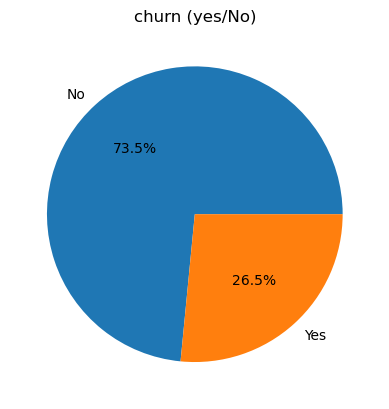

In [12]:
df['Churn Label'].value_counts().plot(kind="pie",autopct='%1.1f%%')
plt.title("churn (yes/No)")
plt.ylabel("")
plt.show()

## 🔹 Data Cleaning 🧹

In [13]:
##Missing Values
df.isnull().sum()
df.isnull().sum().sum()

5174

In [14]:
df.duplicated().sum()

0

In [15]:
# Fix TotalCharges (convert to numeric)
#converting to string to float avoiding NaN " "
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Fill missing values
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

In [16]:
# Drop unnecessary columns if present
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
             'Lat Long', 'Latitude', 'Longitude', 'Churn Score', 'CLTV', 'Churn Reason']

existing_drop_cols = [col for col in drop_cols if col in df.columns]
df.drop(existing_drop_cols, axis=1, inplace=True)

In [17]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
dtype: int64


## 🔹 EDA (Exploratory Data Analysis) 📊

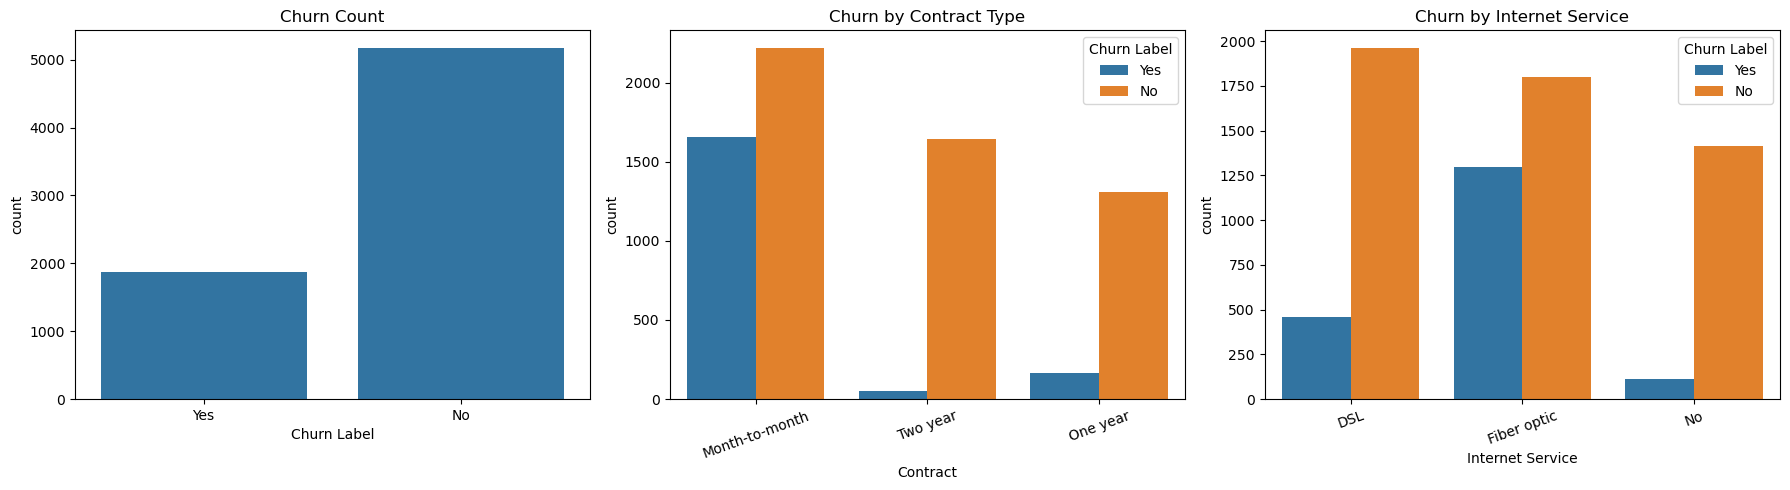

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn count
sns.countplot(x='Churn Label', data=df, ax=axes[0])
axes[0].set_title('Churn Count')

# Check churn by Contract type
sns.countplot(x='Contract', hue='Churn Label', data=df, ax=axes[1])
axes[1].set_title('Churn by Contract Type')
axes[1].tick_params(axis='x', rotation=20)

# Check churn by Internet Service
sns.countplot(x='Internet Service', hue='Churn Label', data=df, ax=axes[2])
axes[2].set_title('Churn by Internet Service')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()



###  check correlations for numeric features:

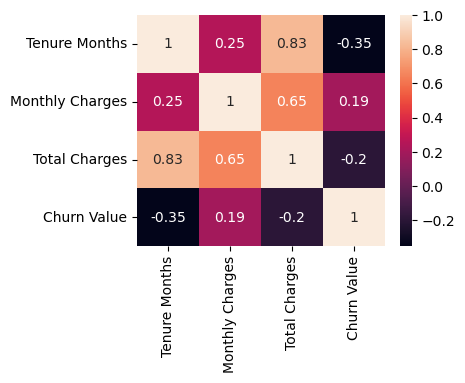

In [19]:
plt.figure(figsize=(4, 3))
sns.heatmap(df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']].corr(), annot=True)
plt.show()



In [20]:
df.groupby('Churn Label')["Monthly Charges"].mean()


Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

In [21]:
df.groupby(['Churn Label','Gender'])["Monthly Charges"].mean()


Churn Label  Gender
No           Female    61.664908
             Male      60.876914
Yes          Female    74.812087
             Male      74.066989
Name: Monthly Charges, dtype: float64

In [22]:
df.groupby('Churn Label')["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

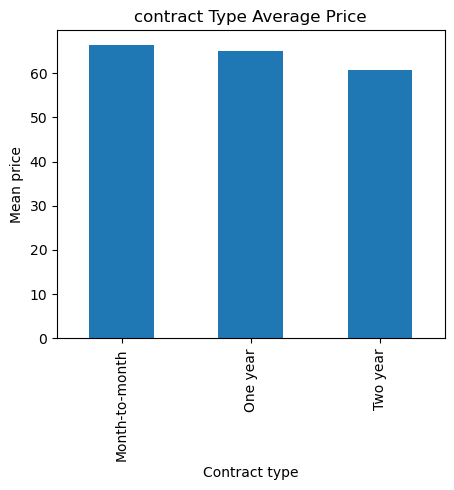

In [23]:
plt.figure(figsize=(5, 4))
df.groupby('Contract')["Monthly Charges"].mean().plot(kind="bar")
plt.ylabel("Mean price")
plt.xlabel("Contract type")
plt.title("contract Type Average Price")
plt.show()

#  Target Variable

In [24]:
# If Churn Value exists, use it directly
if 'Churn Value' in df.columns:
    y = df['Churn Value']
    X = df.drop(['Churn Value', 'Churn Label'], axis=1, errors='ignore')

# If only Churn Label exists
elif 'Churn Label' in df.columns:
    df['Churn Value'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
    y = df['Churn Value']
    X = df.drop(['Churn Value', 'Churn Label'], axis=1, errors='ignore')

# If dataset has column named 'Churn'
elif 'Churn' in df.columns:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    y = df['Churn']
    X = df.drop('Churn', axis=1)

else:
    raise ValueError("Target column not found. Check your churn column name.")

print("\nTarget value counts:")
print(y.value_counts())



Target value counts:
Churn Value
0    5174
1    1869
Name: count, dtype: int64


## Encode Categorical Columns



In [25]:
categorical_cols = X.select_dtypes(include=['object']).columns
print("\nCategorical columns:")
print(categorical_cols)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nEncoded feature shape:")
print(X.shape)



Categorical columns:
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

Encoded feature shape:
(7043, 30)


## Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (5634, 30)
Test shape: (1409, 30)


## Build Random Forest Model

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

##   Predictions

In [28]:
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

## Model Evaluation

In [29]:
# accuracy_score() shows overall correct predictions.
train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
# roc_auc_score() shows how well the model separates churn and non-churn cases.
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\nModel Performance")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("ROC-AUC Score:", roc_auc)

print("\nClassification Report:")
# classification_report() gives detailed model results for each class.
print(classification_report(y_test, y_pred))

# confusion_matrix() shows correct and wrong predictions in table form.
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Model Performance
Training Accuracy: 0.8544550940717075
Testing Accuracy: 0.7714691270404542
ROC-AUC Score: 0.8514647756335736

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


Confusion Matrix:
[[812 223]
 [ 99 275]]


##  Confusion Matrix Plot & ROC Curve
compare actual value with predicted

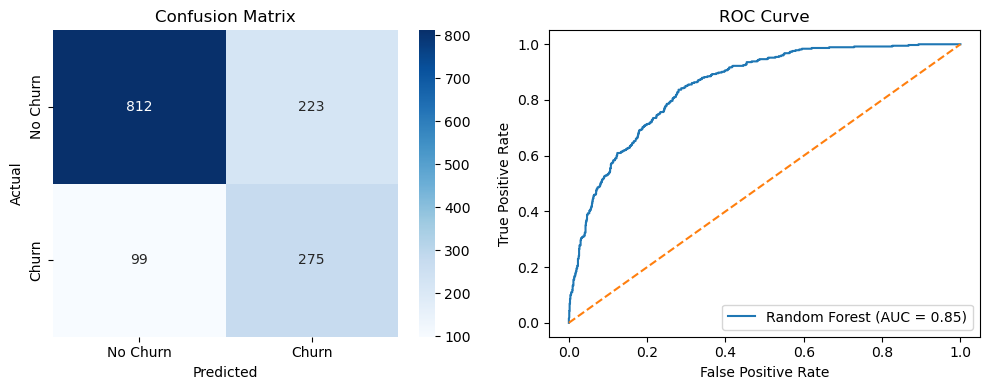

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## Feature Importance


Top 10 Important Features:
                            Feature  Importance
0                     Tenure Months    0.168883
2                     Total Charges    0.128301
25                Contract_Two year    0.101049
1                   Monthly Charges    0.095731
6                    Dependents_Yes    0.078494
10     Internet Service_Fiber optic    0.060167
28  Payment Method_Electronic check    0.051496
24                Contract_One year    0.040692
13              Online Security_Yes    0.030644
19                 Tech Support_Yes    0.020944


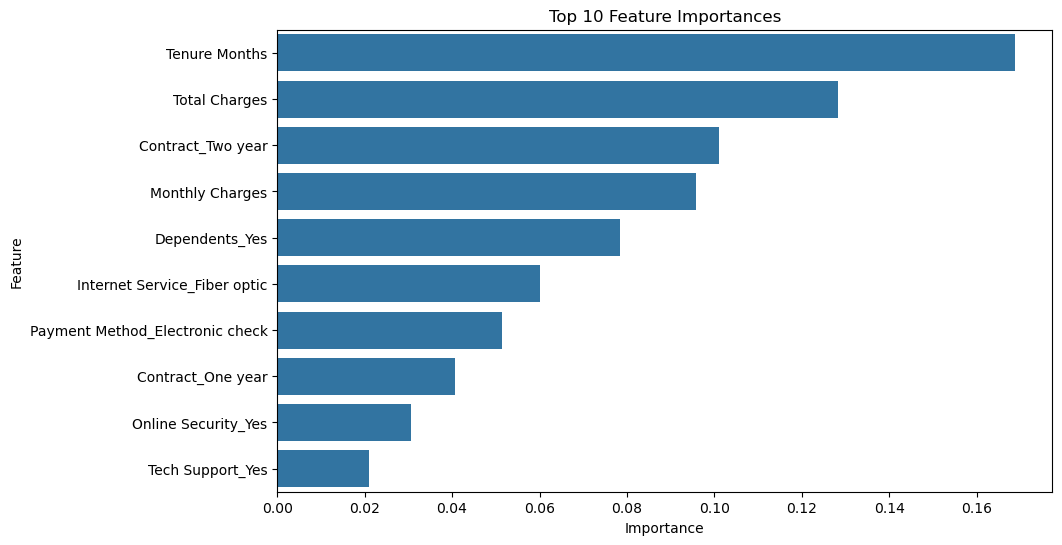

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Feature Importances")
plt.show()


In [32]:
print(y_pred[:10])
print(y_pred_prob[:10])

[0 1 0 1 0 1 1 0 0 1]
[4.55837640e-02 8.65190215e-01 1.87229038e-01 6.10626146e-01
 5.56959649e-02 7.46283902e-01 6.37018169e-01 6.75841046e-02
 8.55716908e-05 6.48592066e-01]


In [33]:
for i, pred in enumerate(y_pred[:10], start=1):
    if pred == 1:
        print(f"Customer {i} -> Churn")
    else:
        print(f"Customer {i} -> No churn")


Customer 1 -> No churn
Customer 2 -> Churn
Customer 3 -> No churn
Customer 4 -> Churn
Customer 5 -> No churn
Customer 6 -> Churn
Customer 7 -> Churn
Customer 8 -> No churn
Customer 9 -> No churn
Customer 10 -> Churn


## Final Conclusion

This project successfully builds a churn prediction pipeline using machine learning on telecom customer data.  
The Random Forest model achieved:

- **Accuracy:** 0.771
- **ROC-AUC:** 0.851

### Top Findings
1. Customers with lower tenure are more likely to churn.
2. Charges (monthly and total) are major churn drivers.
3. Contract type has a strong relationship with churn risk.

### Business Impact
This model can help companies identify high-risk customers and launch proactive retention offers, reducing churn and improving customer lifetime value.

### Next Steps
- Perform hyperparameter tuning
- Add cross-validation
- Test additional models
- Deploy the solution as a simple web app
